In [1]:
import pandas as pd 
import xarray as xr


# Particle Exchange model

$ \frac{dn_k}{dt} = G_1(k) + G_2(k) + G_3(k) - L_1(k) - L_2(k) - L_3(k)$ 

Here, the terms are related as:
1. Aggregation
2. Breakup due to shear
3. Breakup due to collision 

Note that each process can serve as both a loss and a gain to that particle class. 

# Aggregation 
Two-body collision probability function A(i,j) is a function of the shear rate G and the particle diameters $D_i$ and $D_j$

$ G_1(k) = \frac{1}{2} \sum_{i+j=k} \alpha_{ij} A(i,j) n_i n_j$ 

And loss is given by,

$ L_1(k) =  \sum_{i=1}^n \alpha_{ik} A(i,k) n_i n_k$

A(i,j) is given by

$ A(i,j) = \frac{1}{6} G (D_i + D_j)^3 $ 

# Shear break-up 
These terms represent the gain and loss of k-class particles
from the fragmentation of larger flocs (iZk) induced by the
turbulent shear stress. The probability of a k-class floc to breakup
for a given G value is expressed by the fragmentation probability
function Bi as proposed by (Winterwerp, 2002)

$G_2(k) =  \sum_{i= k+1}^n FDBS_{ki} n_i $

$L_2(k) = B_k n_k $ 

$ B_i = \beta_i G^{\beta_2} D_i \left( \frac{D_i - D_p}{D_p} \right)^{\beta_3}$

note that $\beta$ is the fragmentation rate, as a function of floc yield strength .. 

$ \beta_2 = 3/2 $ 

and 

$\beta_3 = 3 - n_f $ 

$FDBS_{ki}$ is the distribution function of fragmented flocs for shear breakup. It's a source of large uncertainty and there's three options to pick and choose from. Simplest is 

$ FDBS_{ij} = 2 $ if $m_j = m_i/2$  
otherwise, $ FDBS_{ij} = 0 $

# Collision-induced breakup 
If the collision-induced shear stress is greater than the strength of the particles, then the collision will cause breakup instead of aggregation. 

$ G_3 (k) = \sum_{i,j} FDBC_{ij} A(i,j) n_i n_j $ 

$ L_3 (k) = \sum_{i=1}^N FDBC_{ik} A(i,k) n_i n_k $  

A is the same as defined earlier. FDBC is a distribution function that looks at whether or not the collision-induced stress exceeds the strength of the particles. 

We calculate the  collision-induced stress for floc i colliding with floc j is given by 

$ T_{ij, i}^c = \frac{8 \left(G(D_i + D_j)/2)\right)^2 m_i m_j}{\pi F_p D_i^2 (D_i + D_j)(m_i + m_j)}$

And floc strength is estimated from floc density, 

$ T_{y,i} = F_y \left(  \frac{\Delta \rho_i}{rho} \right)^{2/(3-n_f)}$ 

Fp represents the relative depth of interparticle penetration and is estimated to be 0.1
F_y is the yield strength ... very empirical and usually assumed to be order 1e-10. 

w_s = 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt




alpha = 1 
G = 1e-3  # shear rate
beta = 0.1 

# **************** Fixed constants ***************
g = 9.81            # gravitational constant [m/s^2]
nu = 1.3e-6         # visosity of water [m^2/s]
rho_w = 1000        # density of water [kg/m^3]
rho_s = 2600        # density of sediment kg/m^3
# ************************************************
nf = 2.5                # fractal dimension exponent
Dp = 4 * 1e-6           # reference diameter (m)
Fy = 1e-10              # yield strength (N)
beta_2 = 1.5            # winterwerp (2002)
beta_3 = 3 - nf         # winterwerp (2002)

N = 200  # number of size classes
D = np.linspace(1e-5, 1e-4, N)  # particle diameters from 1 micron to 1 mm
n = np.zeros(N) + np.linspace(1e5, 1e4, N)  # number concentration in each size class (particles/m^3)


######################### Floc properties #########################
def calculate_w_s(D, floc_density):
    # settling velocity for particle of density floc_density and diameter D
    # returns : settling velocity (m/s)
    ws_ = np.zeros(N)
    for i in range(N):
        ws_[i] = g/(18*nu) * (floc_density[i] - rho_w)/(rho_w) * D[i]**2 
    return ws_

def calculate_density(D):
    # calculate the density of a floc in size class i
    # parameters:
    #   rho_s: particle density (kg/m^3)
    #   D: array of particle diameters (m)
    #   i: index of the particle size class
    #   Dp: reference diameter (m)
    #   nf: fractal dimension exponent
    # returns: density of a particle in size class i (kg/m^3)
    density_ = np.zeros(N)
    for i in range(N):
        density_[i] = rho_w + (rho_s - rho_w) * (Dp/D[i])**(nf - 3)
    return density_


def calculate_mass(D, floc_density):
    # calculate the mass of a floc in size class i
    # parameters:
    #   floc_density: particle density (kg/m^3)
    #   D: array of particle diameters (m)
    #   i: index of the particle size class
    #   Dp: reference diameter (m)
    #   nf: fractal dimension exponent
    # returns: mass of a particle in size class i (kg)
    mass_ = np.zeros(N)
    for i in range(N):
        mass_[i] = floc_density[i] * np.pi/6 * D[i]**3 * (D[i]/Dp)**nf 
    return mass_

floc_density = calculate_density(D)
ws = calculate_w_s(D, floc_density)
mass = calculate_mass(D, floc_density)
mass_ratio = np.zeros((N,N)) 
for i in range(N):
    for j in range(N):
        mass_ratio[i,j] = mass[i]/mass[j]

# calculate once since diameters don't change
collision_matrix = np.zeros((N,N))
for i in range(1,N):
    for j in range(1,N):
        collision_matrix[i,j] = 1/6 * (D[i] + D[j])**3

######################### Aggregation #########################
def A(G, i, j):
    #  Two-body collision probability function A(i,j) is a function of the 
    # shear rate G and the particle diameters D_i and D_j
    # parameters:
    #   G: shear rate (1/s)
    #   D: array of particle diameters (m)
    #   i, j: indices of the particle size classes for particles i and j
    # returns: collision probability between particles i and j (m^3/s) 
    return  G * collision_matrix[i,j]

def g1(k, G):
    # Growth due to collisions for class k 
    # Parameters:
    #   k: index of the particle size class
    #   A : collision probability function
    #   n : number concentration array
    #   G: shear rate (1/s)
    # Returns: growth rate due to aggregation for size class k (particles/m^3/s) 
    g1_ = 0 
    for j in range(k):
        for i in range(k):
            if i + j == k:
                # j = k - i
                g1_ += alpha * A(G,i,j) * n[i] * n[j] #* (mass_ratio[i,k] * mass_ratio[j,k])
    g1_ *= 0.64 #5
    return g1_


# need to fix mass balance with aggregation / loss terms here! 
def l1(k, G):
    # Loss due to collisions for class k
    l1_ = 0 
    for i in range(N-1): # SW was N 
        l1_ += alpha * A(G,i,k) * n[i] * n[k] #* (mass_ratio[i,k])
    return l1_


######################### Shear break-up #########################

def FDBS(k,i):
    # Break-up distribution function
    # What size classes result from a floc breaking up? Using binary assumption 
    # here: a floc breaks into two equal pieces.
    closest = mass[i] - (2*mass)   # SW adding this since no mass is exactly half of another mass
                                   # instead, we find the class w/ the closest mass to half the mass of floc k
    j1 = np.argmin(abs(closest))
    # print(mass[i], mass[k]/2)
    if k == j1 : #mass[i] == mass[k]/2:    
        FDBS_ = 2
    else: 
        FDBS_ = 0
    return FDBS_



# Calculate once since diameters don't change
D_ratio_4_B = np.zeros(N)
for i in range(N):                  # SW adding abs to avoid imaginary numbers
    D_ratio_4_B[i] = D[i] * beta * abs((D[i] - Dp)/Dp)**beta_3


def B(k, G):
    # Bi = beta * G**(beta_2) * D[i] * ((D[i] - Dp)/Dp)**(beta_3)
    Bi = D_ratio_4_B[k] * G**(beta_2)
    return Bi 

def g2(k, G):
    # Growth due to shear break-up for class k
    g2_ = 0
    if k == N:
        return g2_
    for i in range(k+1, N):
        # print(B(k, G))
        g2_ += FDBS(k,i) * B(i, G) * n[i]
    return g2_

def l2(k, G):
    # Loss due to shear break-up for class k
    l2_ = B(k, G) * n[k]
    return l2_


######################### Collision break-up #########################

def g3(k, G):
    g3_ = 0
    for i in range(N):
        for j in range(N):
            g3_ += FDBC(i,j) * A(G,i,j) * n[i] * n[j]
    return g3_

def l3(k, G):
    l3_ = 0
    for i in range(N):
        l3_ += FDBC(i,k) * A(G,i,k) * n[i] * n[k]
    return l3_


def FDBC(i,j):

    tau_c = tau_collision(i,j)
    # tau_y = tau_floc_strength(i)
    # if    strength of floc i > strength of collision 
    # and   strength of floc j < strength of collision
    #    then break-up occurs for particle j only :
    #                   F_j1 and F_j2
    #   the mass of F_j1 = 13/16 of the mass of floc j
    #   the mass of F_j2 =  3/16 of the mass of floc j 
    #   F_j1 is free (!) while F_j2 sticks to floc i
    if (tau_floc_strength(i) > tau_c) & (tau_c > tau_floc_strength(j)):
        fj1 = 13/16 * mass[j]
        fj2 =  3/16 * mass[j]
        
    elif (tau_c  > tau_floc_strength(i)) & (tau_c > tau_floc_strength(j)):
        # flocs i and j break up into (2) pieces each
        fj1 = 13/16 * mass[j]
        fj2 =  3/16 * mass[j]
        fi1 = 13/16 * mass[i]
        fi2 =  3/16 * mass[i]
        # fi2 + fj2 stick together to form a new floc

    return 

def tau_collision(i,j):
    # collision-induced stress for floc i colliding with floc j
    # Parameters:
    #       G: shear rate (1/s)
    #       D: array of particle diameters (m)
    #       i, j: indices of the particle size classes for particles i and j
    #       mass(i): mass of particle i
    #       mass(j): mass of particle j
    #       Fp: relative depth of interparticle penetration and is estimated to be 0.1  (Krone, 1963; McAnally, 1999; McAnally and Mehta, 2001)
    #  
    #  Returns: collision-induced stress (Pa)
    Fp = 0.1  
    T_c = 8 * ((G * (D[i] + D[j])/2)**2 * mass[i] * mass[j])/(np.pi * Fp * D[i]**2 * (D[i] + D[j]) * (mass[i] + mass[j]))
    return T_c

def tau_floc_strength(i):
    # Fy is the 
    Fy = 1e-10 # yield strength
    tau_y = Fy * ((floc_density[i] - rho_w)/rho_w)**(2/(3 - nf))
    return tau_y
#  FDBC is a distribution function that looks at whether or not the collision-induced stress exceeds the strength of the particles. 

# The most sensitive empirical parameters in FLOCMOD are the 
# collisional efficiency α and the fragmentation rate β, which are often assumed to be constants.


In [ ]:

def flocmod_mass_redistribute(n, N):
    """
    Redistribute negative masses in NN toward positive ones,
    setting negatives to zero. converted to python from original fortran code 
    by SW on 1/22/2025 with help from chatgpt. 

    Parameters
    ----------
    n : Number of particles per floc size class 
    N : Number of particle size classes

    Returns
    -------
    n : modified (no negatives) number of particles per floc size class 
    """

    f_mass = mass

    # Temporary copy
    NNtmp = n.copy()

    # Identify negative and positive entries
    neg_mask = n < 0.0
    pos_mask = n > 0.0

    # Toal negative mass (weighted by f_mass)
    mneg = -np.sum(n[neg_mask] * mass[neg_mask])

    # Number of positive bins
    npos = np.sum(pos_mask)

    # Set negative entries to zero in temporary array
    NNtmp[neg_mask] = 0.0

    print("There is negative mass to redistribute: %2.2e" % mneg)
    if mneg > 0.0:
        if npos == 0:
            raise RuntimeError(
                "CAUTION: all floc sizes have negative mass! "
                "Simulation stopped."
            )

        total_positive = NNtmp.sum()

        # Redistribute negative mass linearly over positive classes
        for iv in range(N):
            if n[iv] > 0.0:
                n[iv] = (n[iv]  - (mneg / total_positive)* n[iv]/ f_mass[iv])
            else:
                n[iv] = 0.0

    return n 

There is negative mass to redistribute: -0.00e+00
6.6077955569940325
Ratio =  0.9946493317533538
total gain from agg:  6.0625116786496824e-05
total loss from agg:  6.095124668673705e-05
total gain from shear:  0.001158008774403095
total loss from shear:  0.0011580875819611513
Ratio =  0.9946493317533538
total gain from agg:  6.0625116786496824e-05
total loss from agg:  6.095124668673705e-05
total gain from shear:  0.001158008774403095
total loss from shear:  0.0011580875819611513
Ratio =  0.9946493317533538
total gain from agg:  6.0625116786496824e-05
total loss from agg:  6.095124668673705e-05
total gain from shear:  0.001158008774403095
total loss from shear:  0.0011580875819611513
There is negative mass to redistribute: -0.00e+00
6.60779516071109
There is negative mass to redistribute: -0.00e+00
6.607794773026711
There is negative mass to redistribute: -0.00e+00
6.6077943938850465
There is negative mass to redistribute: -0.00e+00
6.607794023230406
There is negative mass to redistrib

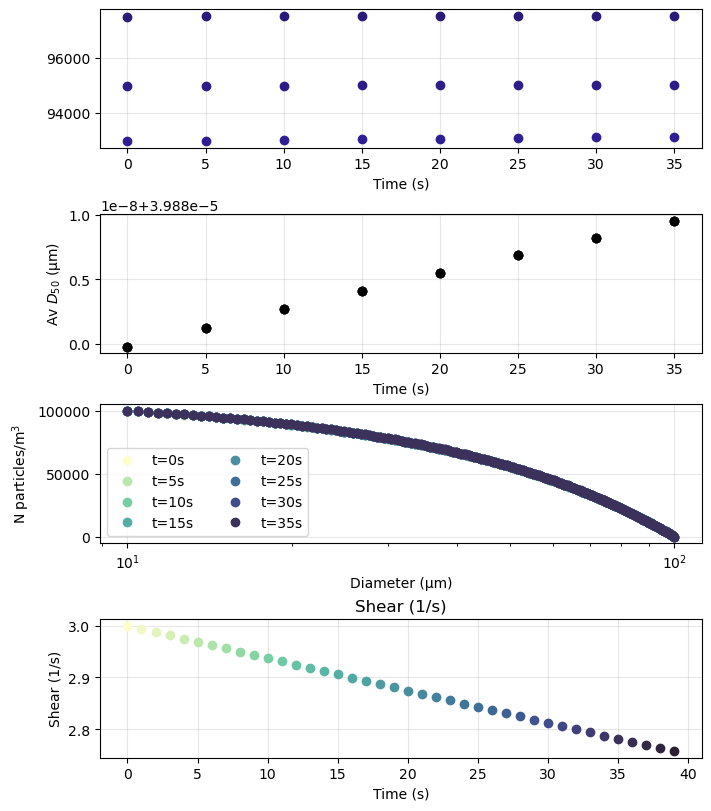

In [ ]:
import cmocean as cmo 
# n = np.zeros(N) + np.linspace(1e5, 1e4, N)  # number concentration in each size class (particles/m^3)

fig , axs = plt.subplots(nrows=4, ncols=1, figsize=(7,8), constrained_layout=True)
axs= axs.flatten()

G = 1e-3
dt = 1

particles2plot = [5, 10, 14] #20, 30] #, 70, 90, 99]
colors = [cmo.cm.haline(k/N) for k in particles2plot]

n = np.zeros(N) + np.linspace(1e5, 1e2, N)  # number concentration in each size class (particles/m^3)

for t in range(40):
    G = 3  - np.sin(t/1000 * 2 * np.pi)   # shear rate varies between 1 and 19 1/s
    axs[3].plot(t, G, 'o', color=cmo.cm.deep(t/40))

    g1_ = np.zeros(N)
    l1_ = np.zeros(N)
    g2_ = np.zeros(N)
    l2_ = np.zeros(N)

    for k in range(1, N):
        g1_[k] = g1(k, G)*dt 
        l1_[k] = l1(k, G)*dt
        g2_[k] = g2(k, G)*dt
        l2_[k] = l2(k, G)*dt


        # agg (+)   agg(-)  shear(+)    shear(-)
    n +=  g1_ -   l1_  +  g2_    -    l2_
    flocmod_mass_redistribute(n, N)
    print(sum(mass * n))
    if t % 5 == 0:
        for k, color in zip(particles2plot, colors):
            axs[0].plot(t, n[k], 'o', color = color) 

            weighted_average = np.average(D, weights=n)
            axs[1].plot(t, weighted_average, 'o', color = 'black')

            print("Ratio = ",(sum(g1_*mass)/sum(l1_*mass)))
            print("total gain from agg: ", sum(g1_*mass))
            print("total loss from agg: ", sum(l1_*mass))
            print("total gain from shear: ", sum(g2_*mass))
            print("total loss from shear: ", sum(l2_*mass))
            
        axs[2].plot(D*1e6, n, 'o', color=cmo.cm.deep(t/40), label=f't={t}s')
  
        
axs[1].set_ylabel("Av $D_{50}$ (μm)")

axs[2].set_xscale('log')
axs[2].legend(loc='lower left', ncols=2, fontsize=10)
axs[2].set_xlabel('Diameter (μm)')
axs[2].set_ylabel('N particles/m$^3$')


axs[3].set_title("Shear (1/s)")
axs[3].set_ylabel("Shear (1/s)")
axs[3].set_xlabel("Time (s)")


axs[0].set_xlabel("Time (s)")
axs[1].set_xlabel("Time (s)")

for ax in axs:
    ax.grid(alpha=0.3)

In [16]:
# # Shear break-up 
# These terms represent the gain and loss of k-class particles
# from the fragmentation of larger flocs (iZk) induced by the
# turbulent shear stress. The probability of a k-class floc to breakup
# for a given G value is expressed by the fragmentation probability
# function Bi as proposed by (Winterwerp, 2002)

# $G_2(k) =  \sum_{i= k+1}^n FDBS_{ki} n_i $

# $L_2(k) = B_k n_k $ 

# $ B_i = \beta_i G^{\beta_2} D_i \left( \frac{D_i - D_p}{D_p} \right)^{\beta_3}

# note that $\beta$ is the fragmentation rate, as a function of floc yield strength .. 

# $ \beta_2 = 3/2 $ 

# and 

# $\beta_3 = 3 - n_f $ 

# $FDBS_{ki}$ is the distribution function of fragmented flocs for shear breakup. It's a source of large uncertainty and there's three options to pick and choose from. Simplest is 

# $ FDBS_{ij} = 2 $ if $m_j = m_i/2$  
# otherwise, $ FDBS_{ij} = 0 $

In [6]:
# and the main floc characteristic sizes in each class i 
# (diameter Di, mass mi and density rf,i) can be expressed via the fractal dimension nf
# mass = rho_s * pi/6 * d50^3 * (Di/Dp)^nf 

# rho_fi = rho + (rho_s - rho) * (Di/Dp)^(nf - 3)
# source_aggregation = 1/2  alpha(i,j) * A(i,j) * n(i) * n(j)
# loss_aggregation(k) = alpha(i,k) * A(i,k) * n(i) * n(k)
# A(i,j)= 1/6 * G * (Di + Dj)^3
# alpha represents particle cohesiveness.. set as a constnat / used for calibration

%history

import pandas as pd 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt




alpha = 1 
G = 1e-3  # shear rate
beta = 0.1 

# **************** Fixed constants ***************
g = 9.81            # gravitational constant [m/s^2]
nu = 1.3e-6         # visosity of water [m^2/s]
rho_w = 1000        # density of water [kg/m^3]
rho_s = 2600        # density of sediment kg/m^3
# ************************************************
nf = 2.5                # fractal dimension exponent
Dp = 4 * 1e-6           # reference diameter (m)
Fy = 1e-10              # yield strength (N)
beta_2 = 1.5            # winterwerp (2002)
beta_3 = 3 - nf         # winterwerp (2002)

N = 50  # number of size classes
D = np.linspace(1e-5, 1e-4, N)  # particle diameters from 1 micron to 1 mm
n = np.zeros(N) + np.linspace(1e5, 1e4, N)  # number concentration in each size class (particles/m^3)


######################### Floc properties #########################
def calculate_w_s(D, floc_density):
    #

In [7]:
import numpy as np 
import matplotlib.pyplot as plt

N = 100 
diameters = np.logspace(-5, -3, N)  # particle diameters from 1 micron to 1 mm
D = diameters**(-3)

plt.plot(diameters, D)
plt.xlabel("Diameter (m)")
ax = plt.gca()
ax.set_yscale('log')

https://www.dropbox.com/scl/fo/f2zogo6y1c5emdq4sbvbu/AHPyW7-LSq1TFRlJQUXDNlY?rlkey=q8a7s1u5yb6iyq6buruxfi0je&st=lizwblku
# TS3000 Optical Backscatter Sensor

SyntaxError: invalid syntax (1091568513.py, line 13)